In [62]:
include("./trajopt/utils.jl")
include("./trajopt/dynamics.jl")
include("./trajopt/constraint.jl")
include("./trajopt/costfunction.jl")
include("./trajopt/scaling.jl")
include("./trajopt/scp.jl")
include("./trajopt/discretize.jl")

discretize_foh

In [ ]:
ix = 3
iu = 2
N = 15
dynamics = Unicycle()

Unicycle(3, 2, 2, 3, 2, 10, 5, 2, 0, [0.0 0.0 1.0; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0; 1.0 0.0; 0.0 0.0], [1.0 0.0; 0.0 1.0; 0.0 0.0], [0.0 0.0; 0.0 0.0; 1.0 0.0], 0.03, 0.05, #undef, #undef, #undef, #undef)

In [113]:
function get_H_obs(rx,ry)
    return diagm([1/rx,1/ry])
end
c_list = []
H_list = []
radius = 0.7
push!(c_list, [1.8,0.3])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [2*2/3,3.5])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [4.2,0.7])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [3.8,3.5])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [10*2/3,0.5])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [6.5,4])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [4*2/3,1.7])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [8*2/3,2.3])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [0.5,2])
push!(H_list, get_H_obs(radius,radius))
push!(c_list, [8,2.3])
push!(H_list, get_H_obs(radius,radius))

10-element Vector{Any}:
 [1.4285714285714286 0.0; 0.0 1.4285714285714286]
 [1.4285714285714286 0.0; 0.0 1.4285714285714286]
 [1.4285714285714286 0.0; 0.0 1.4285714285714286]
 [1.4285714285714286 0.0; 0.0 1.4285714285714286]
 [1.4285714285714286 0.0; 0.0 1.4285714285714286]
 [1.4285714285714286 0.0; 0.0 1.4285714285714286]
 [1.4285714285714286 0.0; 0.0 1.4285714285714286]
 [1.4285714285714286 0.0; 0.0 1.4285714285714286]
 [1.4285714285714286 0.0; 0.0 1.4285714285714286]
 [1.4285714285714286 0.0; 0.0 1.4285714285714286]

In [114]:
vmax = 1.2
vmin = 0
wmax = 1.0
wmin = -1.0
Ac = [1 0;0 1;-1 0;0 -1];
bc = [vmax;wmax;-vmin;-wmin];
input_const = InputLinear(Ac,bc)
obstacle_consts = [Obstacle(H_list[i], c_list[i]) for i in 1:length(H_list)]
list_const = [input_const; obstacle_consts...]

11-element Vector{Constraint}:
 InputLinear([1 0; 0 1; -1 0; 0 -1], [1.2, 1.0, 0.0, 1.0])
 Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [1.8, 0.3])
 Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [1.3333333333333333, 3.5])
 Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [4.2, 0.7])
 Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [3.8, 3.5])
 Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [6.666666666666667, 0.5])
 Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [6.5, 4.0])
 Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [2.6666666666666665, 1.7])
 Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [5.333333333333333, 2.3])
 Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [0.5, 2.0])
 Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [8.0, 2.3])

In [115]:
xi = [0;0;0];
xf = [8;4;0];

In [116]:
x0 = zeros(ix,N+1);
u0 = 0.0*ones(iu,N+1);
tf0 = 10.0;
dt0 = tf0/N*ones(N);
for i = 1:N+1
    x0[:,i] = (N-i+1)/N*xi+(i-1)/N*xf;
end

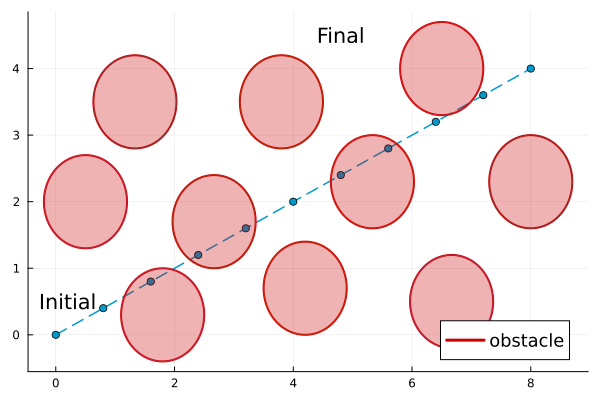

In [117]:
p2 = Plots.plot(; aspect_ratio=:auto)
plot!(x0[1,:], x0[2,:], c=:deepskyblue3, linestyle=:dash, linewidth=1.5, label=nothing)
scatter!(x0[1,:], x0[2,:], c=:deepskyblue3, linewidth=1.5, label=nothing)
for (idx, (ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2, inv(H)*inv(H), ce, "red3", label=label)
end
annotate!(0.2, 0.5, text("Initial", :black, :center))
annotate!(4.8, 4.5, text("Final", :black, :center))
display(p2)
# savefig("./data_image/nominal_trajectory_unicycle.pdf")

In [118]:
xmin = [0;0;0];
xmax = [10;10;pi];
umin = [0;0];
umax = [5;5];
scaler = Scaling(xmin, xmax, umin, umax,1.0)

Scaling([10.0 0.0 0.0; 0.0 10.0 0.0; 0.0 0.0 3.141592653589793], [0.1 0.0 0.0; 0.0 0.1 0.0; 0.0 0.0 0.3183098861837907], [0.0, 0.0, 0.0], [5.0 0.0; 0.0 5.0], [0.2 0.0; 0.0 0.2], [0.0, 0.0], 1.0, 1.0)

In [119]:
max_iter = 30;
w_tf = 0.0;
w_c = 1e-2;
w_rate = 1e-5;
w_param = 0.0;
w_vc = 1e2;
w_tr::Float64 = 1e0;
tol_vc = 1e-6;
tol_tr = 1e-4;
tol_dyn = 1e-1;
tr_norm = "quad";
verbosity = true;

In [120]:
ptr = PTR(N,tf0,max_iter,dynamics,list_const,scaler,
    w_tf,w_c,w_rate,w_param,w_vc,w_tr,
    tol_vc,tol_tr,tol_dyn,
    tr_norm,verbosity)

PTR(Unicycle(3, 2, 2, 3, 2, 10, 5, 2, 0, [0.0 0.0 1.0; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0; 1.0 0.0; 0.0 0.0], [1.0 0.0; 0.0 1.0; 0.0 0.0], [0.0 0.0; 0.0 0.0; 1.0 0.0], 0.03, 0.05, #undef, #undef, #undef, #undef), Constraint[InputLinear([1 0; 0 1; -1 0; 0 -1], [1.2, 1.0, 0.0, 1.0]), Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [1.8, 0.3]), Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [1.3333333333333333, 3.5]), Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [4.2, 0.7]), Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [3.8, 3.5]), Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [6.666666666666667, 0.5]), Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [6.5, 4.0]), Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [2.6666666666666665, 1.7]), Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [5.333333333333333, 2.3]), Obstacle([1.4285714285714286 0.0; 0.0 1.4285714285714286], [0.5, 2.0]), Obstacle([

In [121]:
run(ptr,x0,u0,dt0,xi,xf,"Gurobi")

Set parameter Username
Academic license - for non-commercial use only - expires 2025-11-28
+--------------------------------------------------------------------------------------------------+
|                                   ..:: Penalized Trust Region ::..                               |
+-------+------------+-----------+-----------+-----------+---------+---------+----------+----------+
| iter. |    cost    |    tof    |   main    |   rate    |  param  | log(vc) | log(tr)  | log(dyn) |
+-------+------------+-----------+-----------+-----------+---------+---------+----------+----------+
|1      |40.34       |10.000    |6.816      |0.019      |-1.000    |-0.4     | -0.6     |-1.5e-01   |
|2      |0.49        |10.000    |9.591      |0.202      |-1.000    |-9.4     | -0.4     |-6.9e-01   |
|3      |0.12        |10.000    |10.677     |0.153      |-1.000    |-9.3     | -2.0     |-1.9e+00   |
|4      |0.11        |10.000    |10.472     |0.135      |-1.000    |-8.9     | -3.0     |-3.0e+00 

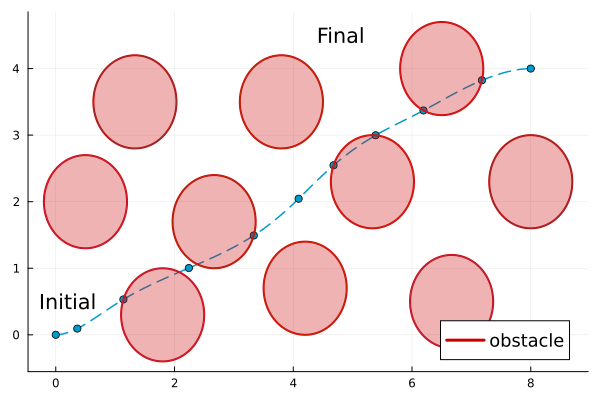

In [122]:
p2 = Plots.plot(; aspect_ratio=:auto)
plot!(ptr.solution.xprop[1,:],ptr.solution.xprop[2,:],c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
scatter!(ptr.solution.x[1,:],ptr.solution.x[2,:],c=:deepskyblue3,linewidth=1.5,label=nothing)
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
annotate!(0.2, 0.5, text("Initial", :black, :center))
annotate!(4.8, 4.5, text("Final", :black, :center))
display(p2)
# savefig("./data_image/nominal_trajectory_unicycle.pdf")

In [123]:
my_dict = Dict("x" => ptr.solution.x, "u" => ptr.solution.u, "t" => ptr.solution.t)

Dict{String, Array{Float64}} with 3 entries:
  "t" => [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
  "x" => [0.0 0.362899 … 7.1775 8.0; 0.0 0.093133 … 3.82374 4.0; 0.0 0.41968 … …
  "u" => [0.169502 0.584725 … 1.1991 0.491375; 0.43692 0.402441 … -0.297177 -0.…

In [124]:
using JLD2, FileIO
# @save "./data/nominal_traj_unicycle_case_long" my_dict

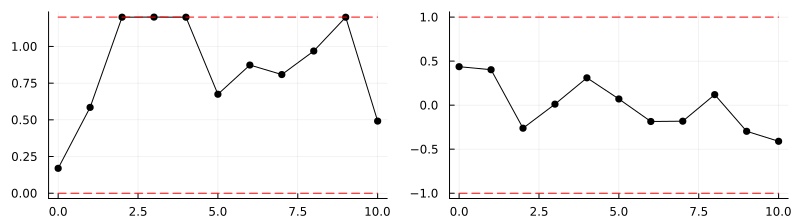

In [125]:
p1 = plot(ptr.solution.t,ptr.solution.u[1,:],seriestype = :scatter,color="black",label="")
plot!(ptr.solution.t,ptr.solution.u[1,:],color="black",label="")
plot!(ptr.solution.t,ptr.solution.t*0 .+ vmax,linestyle=:dash,color="red",label="")
plot!(ptr.solution.t,ptr.solution.t*0 .+ vmin,linestyle=:dash,color="red",label="")
p2 = plot(ptr.solution.t,ptr.solution.u[2,:],seriestype = :scatter,color="black",label="")
plot!(ptr.solution.t,ptr.solution.u[2,:],color="black",label="")
plot!(ptr.solution.t,ptr.solution.t*0 .+ wmax,linestyle=:dash,color="red",label="")
plot!(ptr.solution.t,ptr.solution.t*0 .+ wmin,linestyle=:dash,color="red",label="")
plot(p1,p2,layout=(1,2),size=(800,220))